In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
train = pd.read_csv("train.csv")
store = pd.read_csv("store.csv")


/tmp/ipykernel_57798/2028096367.py:1: DtypeWarning: Columns (7) have mixed types. Specify dtype option on import or set low_memory=False.
  train = pd.read_csv("train.csv")


# **Cleaning Train.csv file**

In [3]:
train.shape

(1017209, 9)

In [4]:
train.sample(5)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
938453,409,2,12-03-2013,2091,273,1,0,0,0
113380,766,2,21-04-2015,4939,458,1,0,0,0
552064,925,6,22-02-2014,8495,1653,1,0,0,0
806295,936,2,09-07-2013,6418,897,1,0,0,0
183812,953,2,17-02-2015,7240,671,1,1,0,0


In [5]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype 
---  ------         --------------    ----- 
 0   Store          1017209 non-null  int64 
 1   DayOfWeek      1017209 non-null  int64 
 2   Date           1017209 non-null  object
 3   Sales          1017209 non-null  int64 
 4   Customers      1017209 non-null  int64 
 5   Open           1017209 non-null  int64 
 6   Promo          1017209 non-null  int64 
 7   StateHoliday   1017209 non-null  object
 8   SchoolHoliday  1017209 non-null  int64 
dtypes: int64(7), object(2)
memory usage: 69.8+ MB


In [6]:
train.describe()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday
count,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06,1.017209e+06
mean,5.584297e+02,3.998341e+00,5.773819e+03,6.331459e+02,8.301067e-01,3.815145e-01,1.786467e-01
std,3.219087e+02,1.997391e+00,3.849926e+03,4.644117e+02,3.755392e-01,4.857586e-01,3.830564e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.727000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00


In [7]:

train['Date'] = pd.to_datetime(train['Date'])


train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017209 entries, 0 to 1017208
Data columns (total 9 columns):
 #   Column         Non-Null Count    Dtype         
---  ------         --------------    -----         
 0   Store          1017209 non-null  int64         
 1   DayOfWeek      1017209 non-null  int64         
 2   Date           1017209 non-null  datetime64[ns]
 3   Sales          1017209 non-null  int64         
 4   Customers      1017209 non-null  int64         
 5   Open           1017209 non-null  int64         
 6   Promo          1017209 non-null  int64         
 7   StateHoliday   1017209 non-null  object        
 8   SchoolHoliday  1017209 non-null  int64         
dtypes: datetime64[ns](1), int64(7), object(1)
memory usage: 69.8+ MB


/tmp/ipykernel_57798/4164677448.py:1: UserWarning: Parsing dates in %d-%m-%Y format when dayfirst=False (the default) was specified. Pass `dayfirst=True` or specify a format to silence this warning.
  train['Date'] = pd.to_datetime(train['Date'])


In [8]:
train.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0


In [9]:
print(f"Number of duplicate rows in 'train': {train.duplicated().sum()}")

Number of duplicate rows in 'train': 0


### Checking for Invalid Values in 'Sales' and 'Customers' Columns

In [10]:
print("Sales Statistics")
display(train['Sales'].describe())

print("\nCustomer Statistics")
display(train['Customers'].describe())

Sales Statistics


,Sales
count,1.017209e+06
mean,5.773819e+03
std,3.849926e+03
min,0.000000e+00
25%,3.727000e+03
50%,5.744000e+03
75%,7.856000e+03
max,4.155100e+04



Customer Statistics


,Customers
count,1.017209e+06
mean,6.331459e+02
std,4.644117e+02
min,0.000000e+00
25%,4.050000e+02
50%,6.090000e+02
75%,8.370000e+02
max,7.388000e+03


In [11]:
print("Negative Sales Records:",
      (train['Sales'] < 0).sum())

print("Negative Customer Records:",
      (train['Customers'] < 0).sum())

Negative Sales Records: 0
Negative Customer Records: 0


In [12]:
validation = {
    "Open store with zero sales":
        ((train['Open'] == 1) & (train['Sales'] == 0)).sum(),

    "Open store with zero customers":
        ((train['Open'] == 1) & (train['Customers'] == 0)).sum(),

    "Closed store with sales":
        ((train['Open'] == 0) & (train['Sales'] > 0)).sum(),

    "Closed store with customers":
        ((train['Open'] == 0) & (train['Customers'] > 0)).sum(),

    "Sales but zero customers":
        ((train['Sales'] > 0) & (train['Customers'] == 0)).sum()
}

pd.DataFrame(validation.items(),
             columns=["Validation Check","Count"])

,Validation Check,Count
0,Open store with zero sales,54
1,Open store with zero customers,52
2,Closed store with sales,0
3,Closed store with customers,0
4,Sales but zero customers,0


In [13]:
for col in ['Open','Promo','SchoolHoliday','StateHoliday']:
    print(f"\n{col}")
    print(train[col].value_counts(dropna=False))


Open
Open
1    844392
0    172817
Name: count, dtype: int64

Promo
Promo
0    629129
1    388080
Name: count, dtype: int64

SchoolHoliday
SchoolHoliday
0    835488
1    181721
Name: count, dtype: int64

StateHoliday
StateHoliday
0    855087
0    131072
a     20260
b      6690
c      4100
Name: count, dtype: int64


In [14]:
print("Start Date :", train['Date'].min())
print("End Date   :", train['Date'].max())

Start Date : 2013-01-01 00:00:00
End Date   : 2015-07-31 00:00:00


In [15]:
train[
    (train['Open'] == 1) &
    (train['Sales'] == 0)
].head(20)

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday
86825,971,5,2015-05-15,0,0,1,0,0,1
142278,674,4,2015-03-26,0,0,1,0,0,0
196938,699,4,2015-02-05,0,0,1,1,0,0
322053,708,3,2014-10-01,0,0,1,1,0,0
330176,357,1,2014-09-22,0,0,1,0,0,0
340348,227,4,2014-09-11,0,0,1,0,0,0
340860,835,4,2014-09-11,0,0,1,0,0,0
341795,835,3,2014-09-10,0,0,1,0,0,0
346232,548,5,2014-09-05,0,0,1,1,0,1
346734,28,4,2014-09-04,0,0,1,1,0,0


In [16]:
train[
    (train['Open'] == 1) &
    (train['Sales'] == 0)
][['Store','Date','Sales','Customers','StateHoliday','SchoolHoliday','Promo']].head(20)

,Store,Date,Sales,Customers,StateHoliday,SchoolHoliday,Promo
86825,971,2015-05-15,0,0,0,1,0
142278,674,2015-03-26,0,0,0,0,0
196938,699,2015-02-05,0,0,0,0,1
322053,708,2014-10-01,0,0,0,0,1
330176,357,2014-09-22,0,0,0,0,0
340348,227,2014-09-11,0,0,0,0,0
340860,835,2014-09-11,0,0,0,0,0
341795,835,2014-09-10,0,0,0,0,0
346232,548,2014-09-05,0,0,0,1,1
346734,28,2014-09-04,0,0,0,0,1


In [17]:
train[
    (train['Open'] == 1) &
    (train['Customers'] == 0)
][['Store','Date','Sales','Customers','StateHoliday','SchoolHoliday','Promo']].head(20)

,Store,Date,Sales,Customers,StateHoliday,SchoolHoliday,Promo
86825,971,2015-05-15,0,0,0,1,0
142278,674,2015-03-26,0,0,0,0,0
196938,699,2015-02-05,0,0,0,0,1
322053,708,2014-10-01,0,0,0,0,1
330176,357,2014-09-22,0,0,0,0,0
340348,227,2014-09-11,0,0,0,0,0
340860,835,2014-09-11,0,0,0,0,0
341795,835,2014-09-10,0,0,0,0,0
346232,548,2014-09-05,0,0,0,1,1
346734,28,2014-09-04,0,0,0,0,1


In [18]:
train = train[
    ~(
        (train['Open'] == 1) &
        (train['Sales'] == 0) &
        (train['Customers'] == 0)
    )
]

In [19]:
validation = {
    "Open store with zero sales":
        ((train['Open'] == 1) & (train['Sales'] == 0)).sum(),

    "Open store with zero customers":
        ((train['Open'] == 1) & (train['Customers'] == 0)).sum(),

    "Closed store with sales":
        ((train['Open'] == 0) & (train['Sales'] > 0)).sum(),

    "Closed store with customers":
        ((train['Open'] == 0) & (train['Customers'] > 0)).sum(),

    "Sales but zero customers":
        ((train['Sales'] > 0) & (train['Customers'] == 0)).sum()
}

pd.DataFrame(validation.items(), columns=["Validation Check", "Count"])

,Validation Check,Count
0,Open store with zero sales,2
1,Open store with zero customers,0
2,Closed store with sales,0
3,Closed store with customers,0
4,Sales but zero customers,0


In [20]:
train[
    (train['Open'] == 1) &
    (train['Sales'] == 0)
][['Store', 'Date', 'Sales', 'Customers', 'StateHoliday',
   'SchoolHoliday', 'Promo', 'DayOfWeek']]


,Store,Date,Sales,Customers,StateHoliday,SchoolHoliday,Promo,DayOfWeek
478649,1100,2014-04-29,0,3,0,0,1,2
889932,948,2013-04-25,0,5,0,0,1,4


In [21]:
train = train[
    ~(
        (train['Open'] == 1) &
        (train['Sales'] == 0)
    )
]

** During data validation, two records were found where stores were marked as open and recorded customer visits, but sales were zero. These observations were considered inconsistent with normal retail operations and were removed to improve data quality.**





# **Cleaning store.csv**

In [22]:
store.shape

(1115, 10)

In [23]:
store.head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [24]:
store.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1115 entries, 0 to 1114
Data columns (total 10 columns):
 #   Column                     Non-Null Count  Dtype  
---  ------                     --------------  -----  
 0   Store                      1115 non-null   int64  
 1   StoreType                  1115 non-null   object 
 2   Assortment                 1115 non-null   object 
 3   CompetitionDistance        1112 non-null   float64
 4   CompetitionOpenSinceMonth  761 non-null    float64
 5   CompetitionOpenSinceYear   761 non-null    float64
 6   Promo2                     1115 non-null   int64  
 7   Promo2SinceWeek            571 non-null    float64
 8   Promo2SinceYear            571 non-null    float64
 9   PromoInterval              571 non-null    object 
dtypes: float64(5), int64(2), object(3)
memory usage: 87.2+ KB


In [25]:
store.describe()

,Store,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1115.00000,1112.000000,761.000000,761.000000,1115.000000,571.000000,571.000000
mean,558.00000,5404.901079,7.224704,2008.668857,0.512108,23.595447,2011.763573
std,322.01708,7663.174720,3.212348,6.195983,0.500078,14.141984,1.674935
min,1.00000,20.000000,1.000000,1900.000000,0.000000,1.000000,2009.000000
25%,279.50000,717.500000,4.000000,2006.000000,0.000000,13.000000,2011.000000
50%,558.00000,2325.000000,8.000000,2010.000000,1.000000,22.000000,2012.000000
75%,836.50000,6882.500000,10.000000,2013.000000,1.000000,37.000000,2013.000000
max,1115.00000,75860.000000,12.000000,2015.000000,1.000000,50.000000,2015.000000


In [26]:
store.duplicated().sum()

np.int64(0)

In [27]:
store['Store'].nunique()

1115

In [28]:
len(store)

1115

In [29]:
store['Store'].duplicated().sum()

np.int64(0)

In [30]:
for col in ['StoreType', 'Assortment', 'Promo2']:
    print(f"\n===== {col} =====")
    display(store[col].value_counts(dropna=False))


===== StoreType =====


,count
StoreType,
a,602
d,348
c,148
b,17



===== Assortment =====


,count
Assortment,
a,593
c,513
b,9



===== Promo2 =====


,count
Promo2,
1,571
0,544


In [31]:
store.isnull().sum()

,0
Store,0
StoreType,0
Assortment,0
CompetitionDistance,3
CompetitionOpenSinceMonth,354
CompetitionOpenSinceYear,354
Promo2,0
Promo2SinceWeek,544
Promo2SinceYear,544
PromoInterval,544


In [32]:
store['CompetitionDistance'].describe()

,CompetitionDistance
count,1112.000000
mean,5404.901079
std,7663.174720
min,20.000000
25%,717.500000
50%,2325.000000
75%,6882.500000
max,75860.000000


In [33]:
store[store['CompetitionDistance'].isnull()]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [34]:
store[
    store['CompetitionOpenSinceMonth'].isnull()
]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...
1095,1096,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1099,1100,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [35]:
store[
    store['CompetitionOpenSinceYear'].isnull()
]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
11,12,a,c,1070.0,NaN,NaN,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
12,13,d,a,310.0,NaN,NaN,1,45.0,2009.0,"Feb,May,Aug,Nov"
15,16,a,c,3270.0,NaN,NaN,0,NaN,NaN,NaN
18,19,a,c,3240.0,NaN,NaN,1,22.0,2011.0,"Mar,Jun,Sept,Dec"
21,22,a,a,1040.0,NaN,NaN,1,22.0,2012.0,"Jan,Apr,Jul,Oct"
...,...,...,...,...,...,...,...,...,...,...
1095,1096,a,c,1130.0,NaN,NaN,1,10.0,2014.0,"Mar,Jun,Sept,Dec"
1099,1100,a,a,540.0,NaN,NaN,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
1112,1113,a,c,9260.0,NaN,NaN,0,NaN,NaN,NaN
1113,1114,a,c,870.0,NaN,NaN,0,NaN,NaN,NaN


In [36]:
store[
    store['Promo2'] == 0
].head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN


In [37]:
store[
    store['Promo2SinceWeek'].isnull()
].head()

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
3,4,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN
5,6,a,a,310.0,12.0,2013.0,0,NaN,NaN,NaN
6,7,a,c,24000.0,4.0,2013.0,0,NaN,NaN,NaN


If a store doesn't participate in Promo2, then:

Promo2SinceWeek Promo2SinceYear PromoInterval are naturally empty

In [38]:
store[
    store['CompetitionDistance'].isnull()
]

,Store,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
290,291,d,a,NaN,NaN,NaN,0,NaN,NaN,NaN
621,622,a,c,NaN,NaN,NaN,0,NaN,NaN,NaN
878,879,d,a,NaN,NaN,NaN,1,5.0,2013.0,"Feb,May,Aug,Nov"


In [39]:
# Fill missing CompetitionDistance values with the median
store['CompetitionDistance'] = store['CompetitionDistance'].fillna(
    store['CompetitionDistance'].median()
)

In [40]:
print("Missing CompetitionDistance values:",
      store['CompetitionDistance'].isnull().sum())

Missing CompetitionDistance values: 0


# MERGING SALES DATA AND STORES **DATA**

In [41]:
df = train.merge(store, on='Store', how='left')

In [42]:
df.shape

(1017155, 18)

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017155 entries, 0 to 1017154
Data columns (total 18 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017155 non-null  int64         
 1   DayOfWeek                  1017155 non-null  int64         
 2   Date                       1017155 non-null  datetime64[ns]
 3   Sales                      1017155 non-null  int64         
 4   Customers                  1017155 non-null  int64         
 5   Open                       1017155 non-null  int64         
 6   Promo                      1017155 non-null  int64         
 7   StateHoliday               1017155 non-null  object        
 8   SchoolHoliday              1017155 non-null  int64         
 9   StoreType                  1017155 non-null  object        
 10  Assortment                 1017155 non-null  object        
 11  CompetitionDistance        1017155 no

In [44]:
df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [45]:
df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,PromoInterval
0,1,5,2015-07-31,5263,555,1,1,0,1,c,a,1270.0,9.0,2008.0,0,NaN,NaN,NaN
1,2,5,2015-07-31,6064,625,1,1,0,1,a,a,570.0,11.0,2007.0,1,13.0,2010.0,"Jan,Apr,Jul,Oct"
2,3,5,2015-07-31,8314,821,1,1,0,1,a,a,14130.0,12.0,2006.0,1,14.0,2011.0,"Jan,Apr,Jul,Oct"
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,c,620.0,9.0,2009.0,0,NaN,NaN,NaN
4,5,5,2015-07-31,4822,559,1,1,0,1,a,a,29910.0,4.0,2015.0,0,NaN,NaN,NaN


In [46]:
df.describe()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear
count,1.017155e+06,1.017155e+06,1017155,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,693826.000000,693826.000000,1.017155e+06,509139.000000,509139.000000
mean,5.584284e+02,3.998356e+00,2014-04-11 01:35:38.651041536,5.774126e+03,6.331796e+02,8.300977e-01,3.815141e-01,1.786444e-01,5.422165e+03,7.222835,2008.690232,5.005520e-01,23.269714,2011.752700
min,1.000000e+00,1.000000e+00,2013-01-01 00:00:00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,1.000000,1900.000000,0.000000e+00,1.000000,2009.000000
25%,2.800000e+02,2.000000e+00,2013-08-17 00:00:00,3.728000e+03,4.050000e+02,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,4.000000,2006.000000,0.000000e+00,13.000000,2011.000000
50%,5.580000e+02,4.000000e+00,2014-04-02 00:00:00,5.744000e+03,6.090000e+02,1.000000e+00,0.000000e+00,0.000000e+00,2.325000e+03,8.000000,2010.000000,1.000000e+00,22.000000,2012.000000
75%,8.380000e+02,6.000000e+00,2014-12-12 00:00:00,7.856000e+03,8.370000e+02,1.000000e+00,1.000000e+00,0.000000e+00,6.880000e+03,10.000000,2013.000000,1.000000e+00,37.000000,2013.000000
max,1.115000e+03,7.000000e+00,2015-07-31 00:00:00,4.155100e+04,7.388000e+03,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,12.000000,2015.000000,1.000000e+00,50.000000,2015.000000
std,3.219078e+02,1.997420e+00,NaN,3.849799e+03,4.644012e+02,3.755472e-01,4.857585e-01,3.830544e-01,7.707027e+03,3.211810,5.992658,4.999999e-01,14.096037,1.662857


# **EDA**

**1.Sales Analysis**

In [47]:
display(df['Sales'].describe())

,Sales
count,1.017155e+06
mean,5.774126e+03
std,3.849799e+03
min,0.000000e+00
25%,3.728000e+03
50%,5.744000e+03
75%,7.856000e+03
max,4.155100e+04


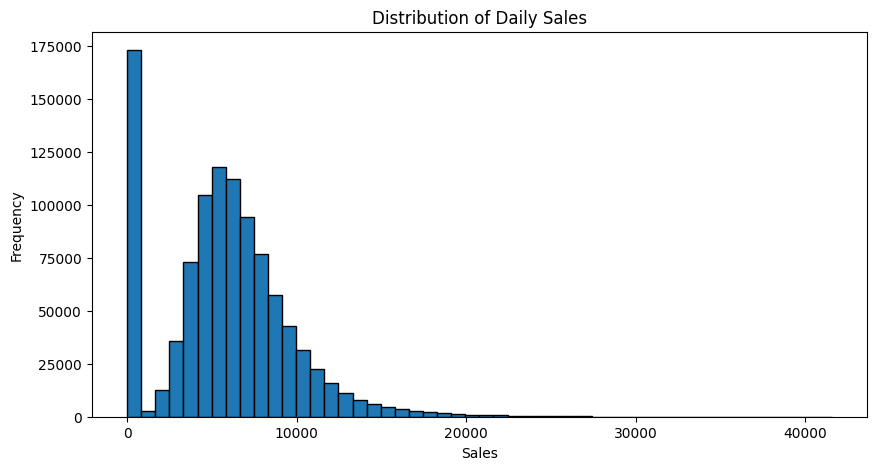

In [48]:
plt.figure(figsize=(10,5))
plt.hist(df['Sales'], bins=50, edgecolor='black')
plt.title("Distribution of Daily Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

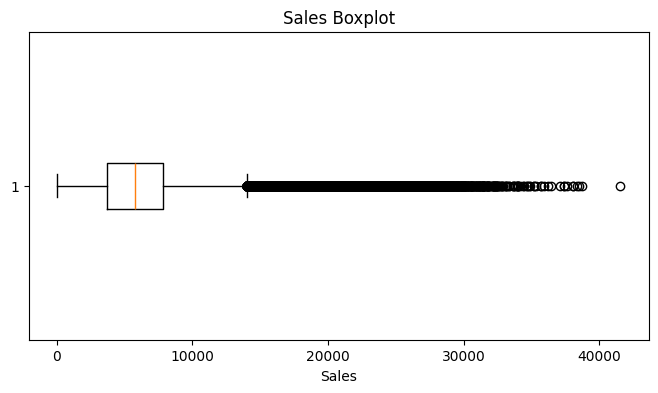

In [49]:
plt.figure(figsize=(8,4))
plt.boxplot(df['Sales'], vert=False)
plt.title("Sales Boxplot")
plt.xlabel("Sales")
plt.show()

**2.Customer Analysis**

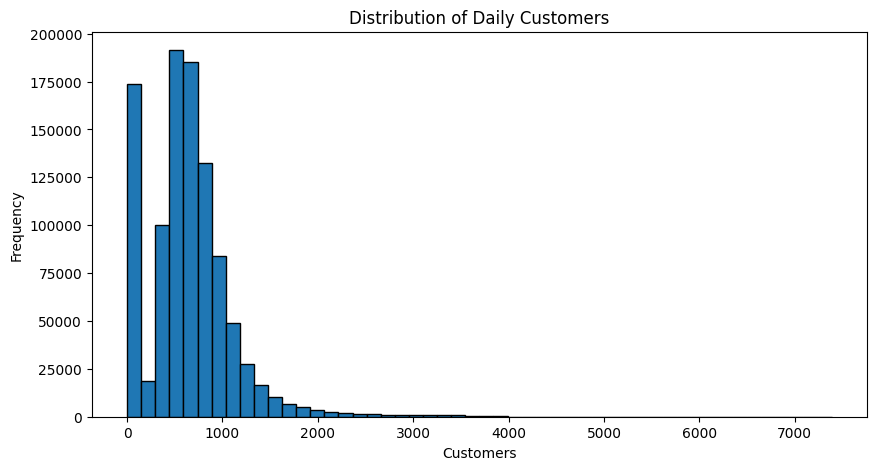

In [50]:
plt.figure(figsize=(10,5))
plt.hist(df['Customers'], bins=50, edgecolor='black')
plt.title("Distribution of Daily Customers")
plt.xlabel("Customers")
plt.ylabel("Frequency")
plt.show()

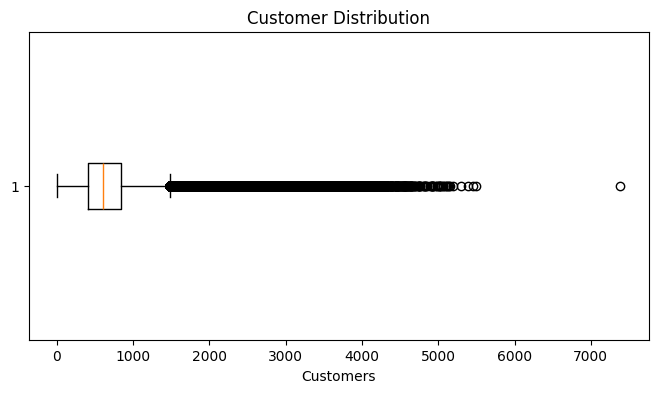

In [51]:
plt.figure(figsize=(8,4))
plt.boxplot(df['Customers'], vert=False)
plt.title("Customer Distribution")
plt.xlabel("Customers")
plt.show()

**3.Promotion Distribution**

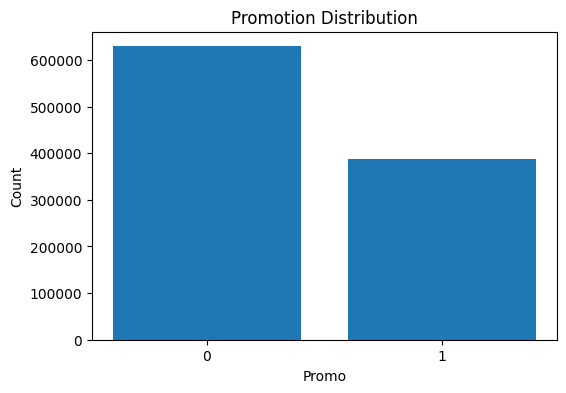

In [52]:
promo_counts = df['Promo'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    promo_counts.index.astype(str),
    promo_counts.values
)

plt.title("Promotion Distribution")
plt.xlabel("Promo")
plt.ylabel("Count")
plt.show()

**4.Store Type Distribution**

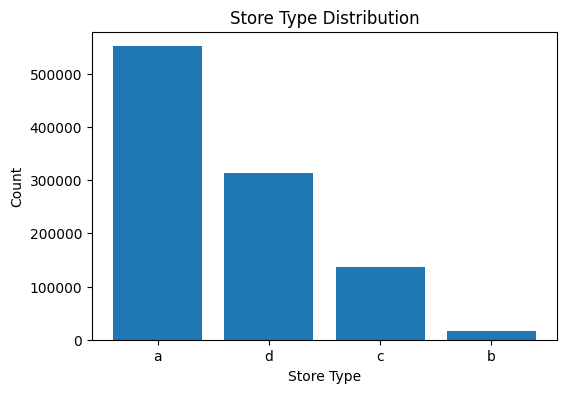

In [53]:
store_counts = df['StoreType'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    store_counts.index,
    store_counts.values
)

plt.title("Store Type Distribution")
plt.xlabel("Store Type")
plt.ylabel("Count")
plt.show()

**5.Assortment Distribution**

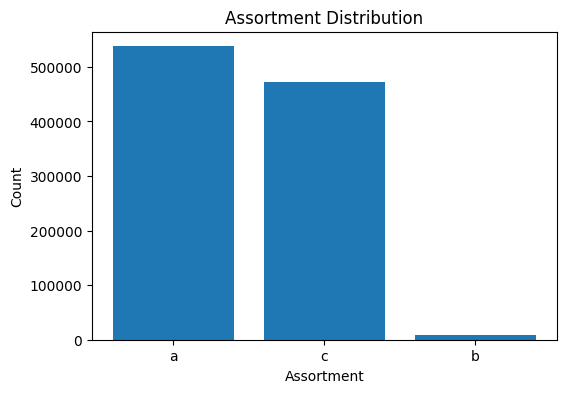

In [54]:
assortment_counts = df['Assortment'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(
    assortment_counts.index,
    assortment_counts.values
)

plt.title("Assortment Distribution")
plt.xlabel("Assortment")
plt.ylabel("Count")
plt.show()

**6.Competition Distance**

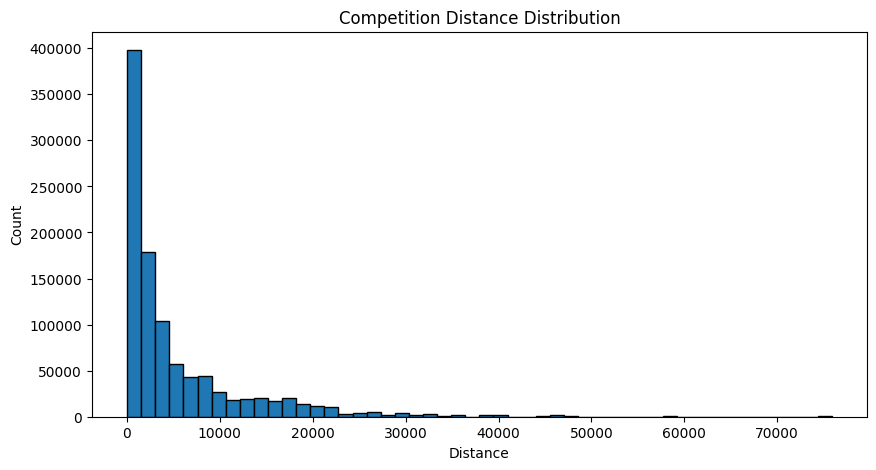

In [55]:
plt.figure(figsize=(10,5))
plt.hist(
    df['CompetitionDistance'],
    bins=50,
    edgecolor='black'
)

plt.title("Competition Distance Distribution")
plt.xlabel("Distance")
plt.ylabel("Count")
plt.show()

**7.State Holiday**

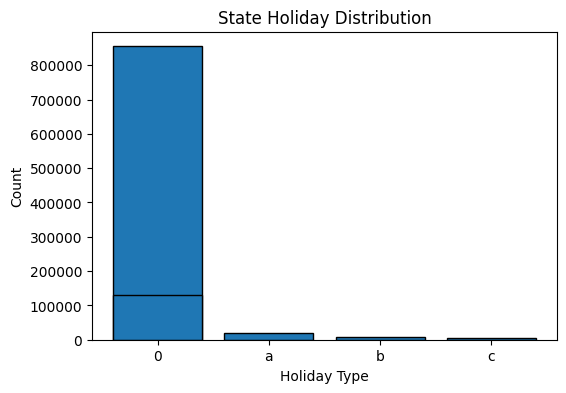

In [56]:
holiday = df['StateHoliday'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(holiday.index.astype(str),
        holiday.values,
        edgecolor='black')

plt.title("State Holiday Distribution")
plt.xlabel("Holiday Type")
plt.ylabel("Count")
plt.show()

**8.School Holiday**

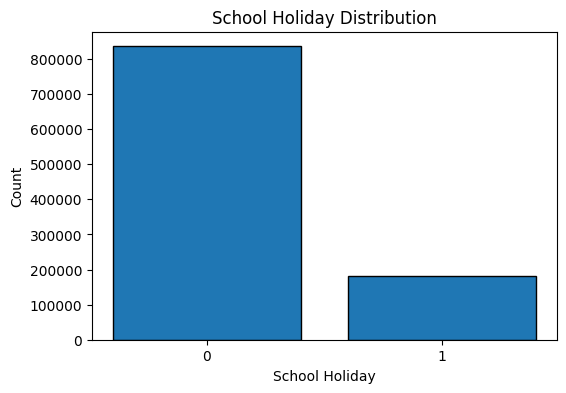

In [57]:
school = df['SchoolHoliday'].value_counts()

plt.figure(figsize=(6,4))
plt.bar(school.index.astype(str),
        school.values,
        edgecolor='black')

plt.title("School Holiday Distribution")
plt.xlabel("School Holiday")
plt.ylabel("Count")
plt.show()

# **Bivariate Analysis**

**1.Sales vs Promotion**

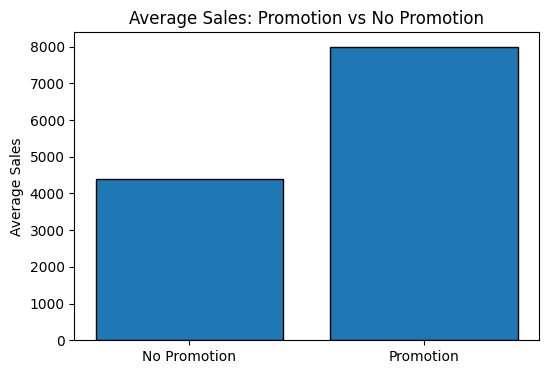

In [58]:
promo_sales = df.groupby('Promo')['Sales'].mean()

plt.figure(figsize=(6,4))
plt.bar(
    ['No Promotion', 'Promotion'],
    promo_sales.values,
    edgecolor='black'
)

plt.title("Average Sales: Promotion vs No Promotion")
plt.ylabel("Average Sales")
plt.show()

/tmp/ipykernel_57798/1511008705.py:2: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot(


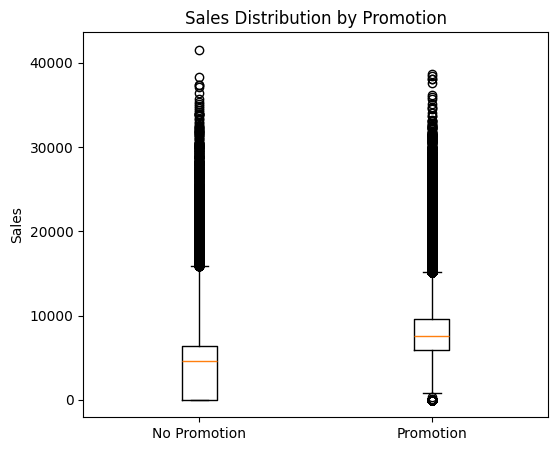

In [59]:
plt.figure(figsize=(6,5))
plt.boxplot(
    [
        df[df['Promo']==0]['Sales'],
        df[df['Promo']==1]['Sales']
    ],
    labels=['No Promotion','Promotion']
)

plt.title("Sales Distribution by Promotion")
plt.ylabel("Sales")
plt.show()

**2.Customers vs Promotion**

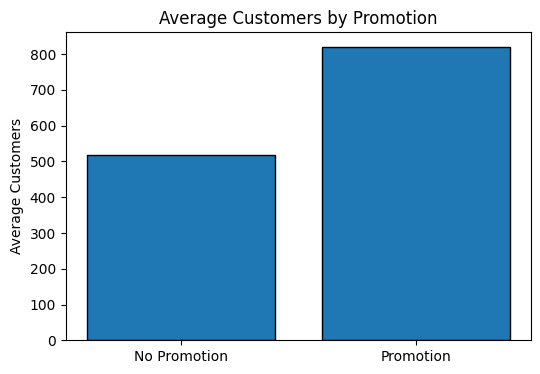

In [60]:
promo_customers = df.groupby('Promo')['Customers'].mean()

plt.figure(figsize=(6,4))
plt.bar(
    ['No Promotion','Promotion'],
    promo_customers.values,
    edgecolor='black'
)

plt.title("Average Customers by Promotion")
plt.ylabel("Average Customers")
plt.show()

**3.Store Type vs Sales**

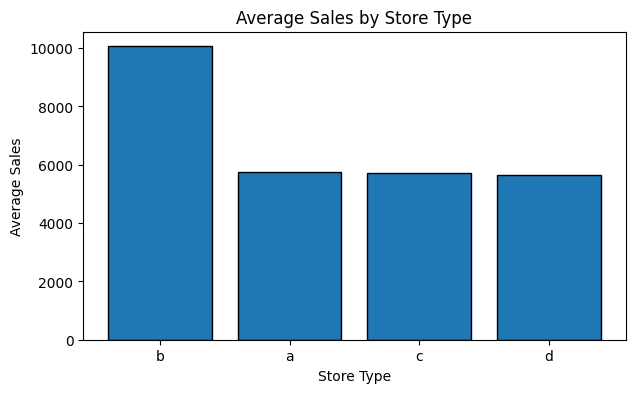

In [61]:
store_sales = df.groupby('StoreType')['Sales'].mean().sort_values(ascending=False)

plt.figure(figsize=(7,4))
plt.bar(
    store_sales.index,
    store_sales.values,
    edgecolor='black'
)

plt.title("Average Sales by Store Type")
plt.xlabel("Store Type")
plt.ylabel("Average Sales")
plt.show()

**4.Assortment vs Sales**

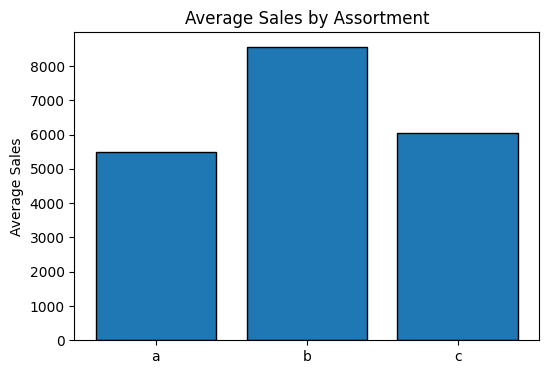

In [62]:
assortment_sales = df.groupby('Assortment')['Sales'].mean()

plt.figure(figsize=(6,4))
plt.bar(
    assortment_sales.index,
    assortment_sales.values,
    edgecolor='black'
)

plt.title("Average Sales by Assortment")
plt.ylabel("Average Sales")
plt.show()

**5.Customers vs Sales**

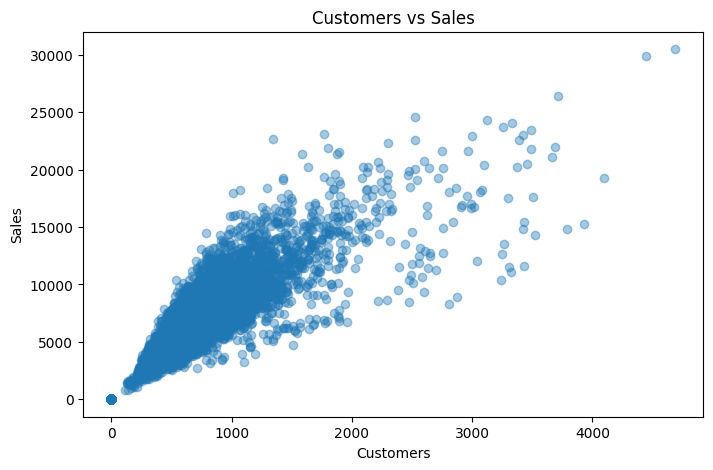

In [63]:
sample = df.sample(10000, random_state=42)

plt.figure(figsize=(8,5))
plt.scatter(
    sample['Customers'],
    sample['Sales'],
    alpha=0.4
)

plt.title("Customers vs Sales")
plt.xlabel("Customers")
plt.ylabel("Sales")
plt.show()

**6.Competition Distance vs Sales**

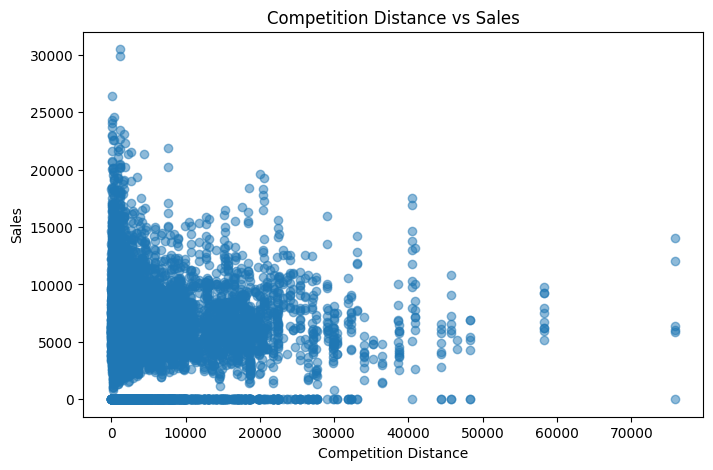

In [64]:
sample = df.sample(10000, random_state=42)

plt.figure(figsize=(8,5))
plt.scatter(
    sample['CompetitionDistance'],
    sample['Sales'],
    alpha=0.5
)

plt.title("Competition Distance vs Sales")
plt.xlabel("Competition Distance")
plt.ylabel("Sales")
plt.show()

**7.School Holiday vs Sales**

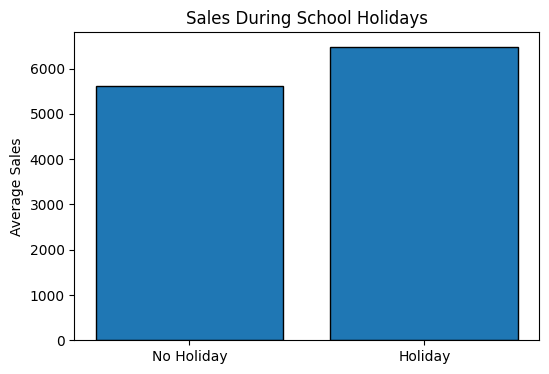

In [65]:
holiday_sales = df.groupby('SchoolHoliday')['Sales'].mean()

plt.figure(figsize=(6,4))
plt.bar(
    ['No Holiday','Holiday'],
    holiday_sales.values,
    edgecolor='black'
)

plt.title("Sales During School Holidays")
plt.ylabel("Average Sales")
plt.show()

# **Time Series Analysis**

**1.Monthly Sales Trend**

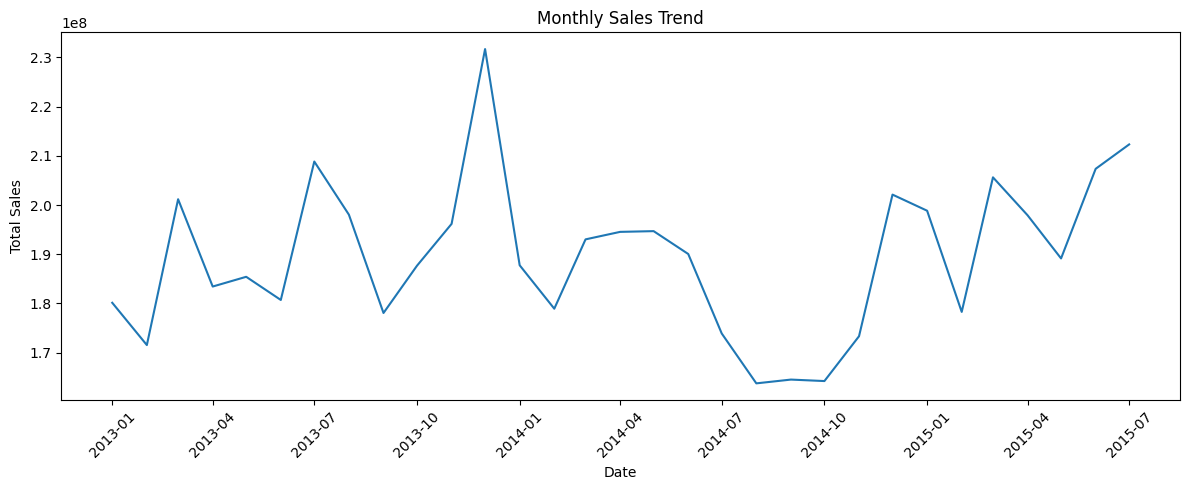

In [66]:
monthly_sales = (
    df.groupby(df['Date'].dt.to_period('M'))['Sales']
      .sum()
      .reset_index()
)

monthly_sales['Date'] = monthly_sales['Date'].dt.to_timestamp()

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales['Date'],
    monthly_sales['Sales']
)

plt.title("Monthly Sales Trend")
plt.xlabel("Date")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

**2.Monthly Customer Trend**

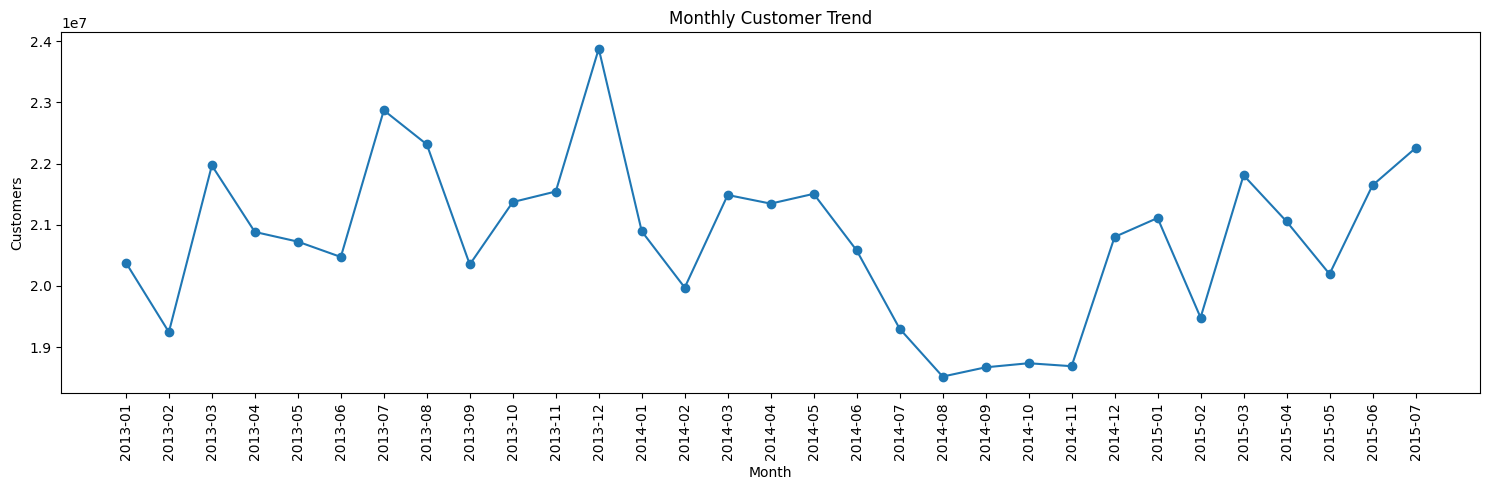

In [67]:
df['Year'] = df['Date'].dt.year
df['Month'] = df['Date'].dt.month

monthly_customers = (
    df.groupby(['Year', 'Month'])['Customers']
      .sum()
      .reset_index()
)

monthly_customers['YearMonth'] = (
    monthly_customers['Year'].astype(str)
    + "-"
    + monthly_customers['Month'].astype(str).str.zfill(2)
)

plt.figure(figsize=(15, 5))

plt.plot(
    monthly_customers['YearMonth'],
    monthly_customers['Customers'],
    marker='o'
)

plt.xticks(rotation=90)

plt.title("Monthly Customer Trend")
plt.xlabel("Month")
plt.ylabel("Customers")

plt.tight_layout()
plt.show()

**3.Sales by Month**

In [68]:
df['MonthName'] = df['Date'].dt.month_name()

month_sales = (
    df.groupby('MonthName')['Sales']
      .mean()
)

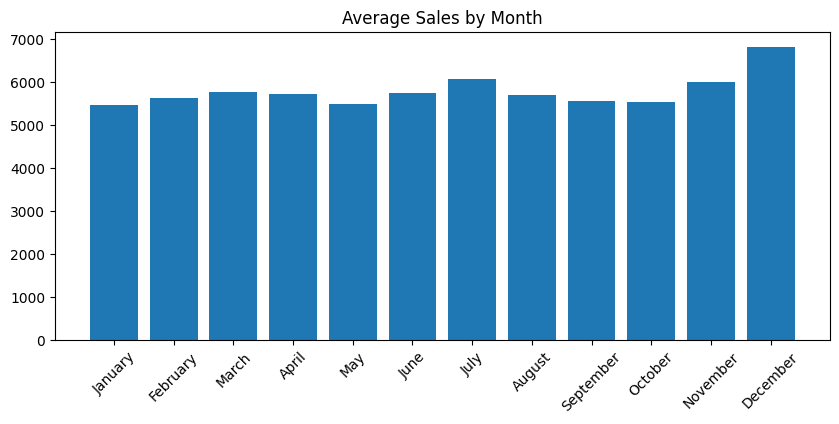

In [69]:
order = [
'January',
'February',
'March',
'April',
'May',
'June',
'July',
'August',
'September',
'October',
'November',
'December'
]

month_sales = month_sales.reindex(order)

plt.figure(figsize=(10,4))

plt.bar(
    month_sales.index,
    month_sales.values
)

plt.xticks(rotation=45)

plt.title("Average Sales by Month")

plt.show()

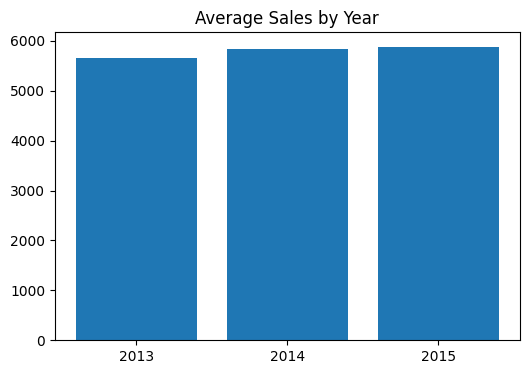

In [70]:
year_sales = (
    df.groupby('Year')['Sales']
      .mean()
)

plt.figure(figsize=(6,4))

plt.bar(
    year_sales.index.astype(str),
    year_sales.values
)

plt.title("Average Sales by Year")

plt.show()

In [71]:
promo_trend = (
    df.groupby(['Year','Month','Promo'])['Sales']
      .mean()
      .reset_index()
)

# **Correlation & Feature Analysis**

In [72]:
numeric_df = df.select_dtypes(include=['number'])

numeric_df.head()

,Store,DayOfWeek,Sales,Customers,Open,Promo,SchoolHoliday,CompetitionDistance,CompetitionOpenSinceMonth,CompetitionOpenSinceYear,Promo2,Promo2SinceWeek,Promo2SinceYear,Year,Month
0,1,5,5263,555,1,1,1,1270.0,9.0,2008.0,0,NaN,NaN,2015,7
1,2,5,6064,625,1,1,1,570.0,11.0,2007.0,1,13.0,2010.0,2015,7
2,3,5,8314,821,1,1,1,14130.0,12.0,2006.0,1,14.0,2011.0,2015,7
3,4,5,13995,1498,1,1,1,620.0,9.0,2009.0,0,NaN,NaN,2015,7
4,5,5,4822,559,1,1,1,29910.0,4.0,2015.0,0,NaN,NaN,2015,7


In [73]:
corr_sales = (
    numeric_df.corr()['Sales']
    .sort_values(ascending=False)
)

display(corr_sales)

,Sales
Sales,1.000000
Customers,0.894700
Open,0.678553
Promo,0.452385
SchoolHoliday,0.085141
Promo2SinceWeek,0.059497
Month,0.048758
Year,0.023508
CompetitionOpenSinceYear,0.012659
Store,0.005133


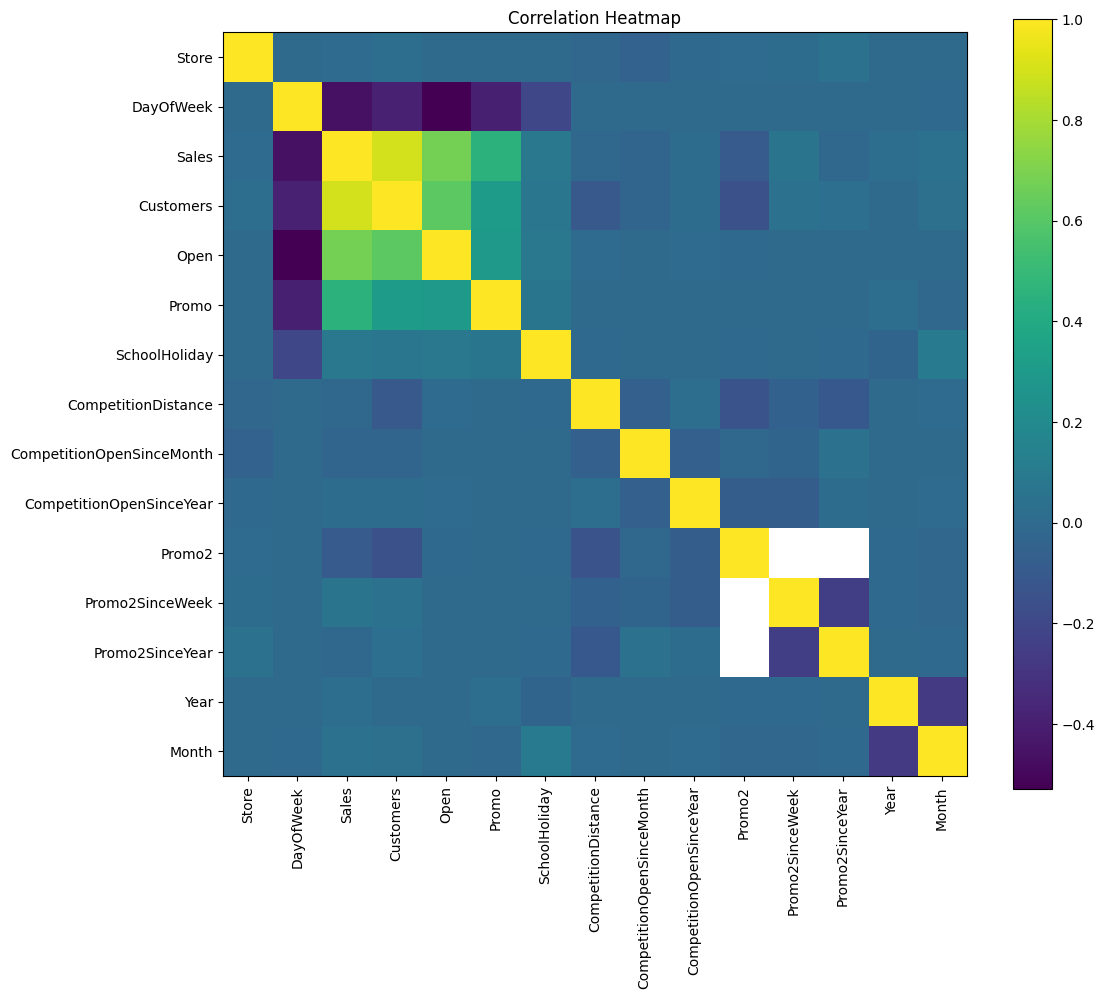

In [74]:
corr = numeric_df.corr()

plt.figure(figsize=(12,10))

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)),
           corr.columns,
           rotation=90)

plt.yticks(range(len(corr.columns)),
           corr.columns)

plt.title("Correlation Heatmap")

plt.show()

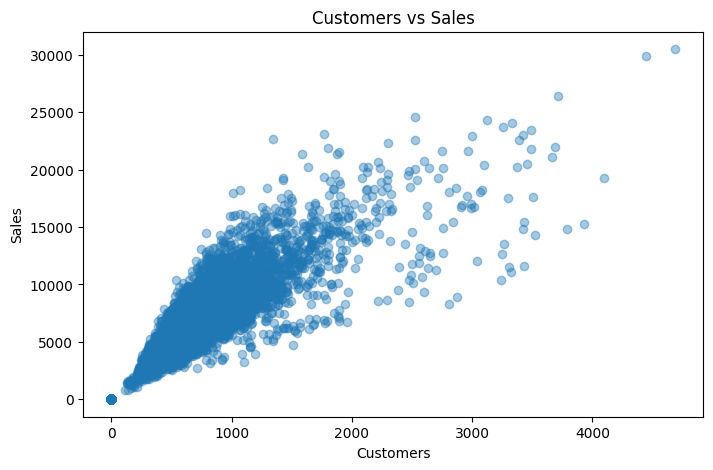

In [75]:
sample = df.sample(10000, random_state=42)

plt.figure(figsize=(8,5))

plt.scatter(
    sample['Customers'],
    sample['Sales'],
    alpha=0.4
)

plt.title("Customers vs Sales")

plt.xlabel("Customers")

plt.ylabel("Sales")

plt.show()

In [76]:
corr_sales.to_frame()

,Sales
Sales,1.000000
Customers,0.894700
Open,0.678553
Promo,0.452385
SchoolHoliday,0.085141
Promo2SinceWeek,0.059497
Month,0.048758
Year,0.023508
CompetitionOpenSinceYear,0.012659
Store,0.005133


# **EDA Summary**

## Key Findings from EDA

• Daily sales exhibit a right-skewed distribution with a small number of extremely high-sales days.

• Customer footfall strongly correlates with daily sales, making it one of the most influential predictors.

• Promotional campaigns significantly improve both customer traffic and sales.

• Store performance varies across different Store Types and Assortment strategies.

• Sales demonstrate clear seasonal trends, with noticeable monthly fluctuations.

• Competition Distance shows only a weak relationship with sales.

• Holiday periods influence sales differently depending on the holiday type.

• No major data quality issues remained after cleaning except business-related missing values, which will be handled during feature engineering.

# **Feature Engineering & Preprocessing**

In [77]:
print("Dataset shape:", df.shape)

print("\nColumns:")
for i, col in enumerate(df.columns, 1):
    print(f"{i}. {col}")

Dataset shape: (1017155, 21)

Columns:
1. Store
2. DayOfWeek
3. Date
4. Sales
5. Customers
6. Open
7. Promo
8. StateHoliday
9. SchoolHoliday
10. StoreType
11. Assortment
12. CompetitionDistance
13. CompetitionOpenSinceMonth
14. CompetitionOpenSinceYear
15. Promo2
16. Promo2SinceWeek
17. Promo2SinceYear
18. PromoInterval
19. Year
20. Month
21. MonthName


In [78]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017155 entries, 0 to 1017154
Data columns (total 21 columns):
 #   Column                     Non-Null Count    Dtype         
---  ------                     --------------    -----         
 0   Store                      1017155 non-null  int64         
 1   DayOfWeek                  1017155 non-null  int64         
 2   Date                       1017155 non-null  datetime64[ns]
 3   Sales                      1017155 non-null  int64         
 4   Customers                  1017155 non-null  int64         
 5   Open                       1017155 non-null  int64         
 6   Promo                      1017155 non-null  int64         
 7   StateHoliday               1017155 non-null  object        
 8   SchoolHoliday              1017155 non-null  int64         
 9   StoreType                  1017155 non-null  object        
 10  Assortment                 1017155 non-null  object        
 11  CompetitionDistance        1017155 no

In [79]:
df.isnull().sum()

,0
Store,0
DayOfWeek,0
Date,0
Sales,0
Customers,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0


In [80]:
model_df = df.copy()

In [81]:
model_df['Date'] = pd.to_datetime(model_df['Date'])

In [82]:
print(sorted(df['DayOfWeek'].unique()))

[np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7)]


In [83]:
model_df['Year'] = model_df['Date'].dt.year
model_df['Month'] = model_df['Date'].dt.month
model_df['Day'] = model_df['Date'].dt.day
model_df['WeekOfYear'] = model_df['Date'].dt.isocalendar().week.astype(int)
model_df['Quarter'] = model_df['Date'].dt.quarter

model_df['IsWeekend'] = (
    model_df['DayOfWeek'].isin([6, 7])
).astype(int)

In [84]:
model_df['CompetitionInfoMissing'] = (
    model_df['CompetitionOpenSinceYear'].isna() |
    model_df['CompetitionOpenSinceMonth'].isna()
).astype(int)

In [85]:
model_df['CompetitionMonths'] = (
    (model_df['Year'] - model_df['CompetitionOpenSinceYear']) * 12
    +
    (model_df['Month'] - model_df['CompetitionOpenSinceMonth'])
)

In [86]:
model_df['CompetitionMonths'] = (
    model_df['CompetitionMonths'].clip(lower=0)
)

In [87]:
model_df['CompetitionMonths'] = (
    model_df['CompetitionMonths'].fillna(0)
)

In [88]:
model_df.head()

,Store,DayOfWeek,Date,Sales,Customers,Open,Promo,StateHoliday,SchoolHoliday,StoreType,...,PromoInterval,Year,Month,MonthName,Day,WeekOfYear,Quarter,IsWeekend,CompetitionInfoMissing,CompetitionMonths
0,1,5,2015-07-31,5263,555,1,1,0,1,c,...,NaN,2015,7,July,31,31,3,0,0,82.0
1,2,5,2015-07-31,6064,625,1,1,0,1,a,...,"Jan,Apr,Jul,Oct",2015,7,July,31,31,3,0,0,92.0
2,3,5,2015-07-31,8314,821,1,1,0,1,a,...,"Jan,Apr,Jul,Oct",2015,7,July,31,31,3,0,0,103.0
3,4,5,2015-07-31,13995,1498,1,1,0,1,c,...,NaN,2015,7,July,31,31,3,0,0,70.0
4,5,5,2015-07-31,4822,559,1,1,0,1,a,...,NaN,2015,7,July,31,31,3,0,0,3.0


In [89]:
promo_year = model_df['Promo2SinceYear'].fillna(2000).astype(int)
promo_week = model_df['Promo2SinceWeek'].fillna(1).astype(int)

promo_date_string = (
    promo_year.astype(str)
    + '-W'
    + promo_week.astype(str).str.zfill(2)
    + '-1'
)

model_df['Promo2StartDate'] = pd.to_datetime(
    promo_date_string,
    format='%G-W%V-%u',
    errors='coerce'
)

In [90]:
model_df['Promo2Months'] = (
    (model_df['Date'] - model_df['Promo2StartDate']).dt.days / 30.44
)

In [91]:
model_df['Promo2Months'] = (
    model_df['Promo2Months'].clip(lower=0)
)

In [92]:
model_df.loc[
    model_df['Promo2'] == 0,
    'Promo2Months'
] = 0

In [93]:
month_map = {
    1: 'Jan',
    2: 'Feb',
    3: 'Mar',
    4: 'Apr',
    5: 'May',
    6: 'Jun',
    7: 'Jul',
    8: 'Aug',
    9: 'Sept',
    10: 'Oct',
    11: 'Nov',
    12: 'Dec'
}

model_df['MonthShort'] = model_df['Month'].map(month_map)

In [94]:
model_df['Promo2ThisMonth'] = model_df.apply(
    lambda row:
        1 if (
            row['Promo2'] == 1
            and pd.notna(row['PromoInterval'])
            and row['MonthShort'] in row['PromoInterval'].split(',')
        )
        else 0,
    axis=1
)

In [95]:
model_df.drop(columns=['Customers'], inplace=True)

In [96]:
categorical_features = [
    'StateHoliday',
    'StoreType',
    'Assortment'
]

In [97]:
columns_to_drop = [
    'Date',
    'CompetitionOpenSinceMonth',
    'CompetitionOpenSinceYear',
    'Promo2SinceWeek',
    'Promo2SinceYear',
    'PromoInterval',
    'Promo2StartDate',
    'MonthShort'
]

model_df.drop(
    columns=columns_to_drop,
    inplace=True,
    errors='ignore'
)

In [98]:
model_df.drop(
    columns=['MonthName', 'DayName'],
    inplace=True,
    errors='ignore'
)

In [99]:
model_df.head()

,Store,DayOfWeek,Sales,Open,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,...,Year,Month,Day,WeekOfYear,Quarter,IsWeekend,CompetitionInfoMissing,CompetitionMonths,Promo2Months,Promo2ThisMonth
0,1,5,5263,1,1,0,1,c,a,1270.0,...,2015,7,31,31,3,0,0,82.0,0.000000,0
1,2,5,6064,1,1,0,1,a,a,570.0,...,2015,7,31,31,3,0,0,92.0,64.060447,1
2,3,5,8314,1,1,0,1,a,a,14130.0,...,2015,7,31,31,3,0,0,103.0,51.872536,1
3,4,5,13995,1,1,0,1,c,c,620.0,...,2015,7,31,31,3,0,0,70.0,0.000000,0
4,5,5,4822,1,1,0,1,a,a,29910.0,...,2015,7,31,31,3,0,0,3.0,0.000000,0


In [100]:
model_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1017155 entries, 0 to 1017154
Data columns (total 21 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   Store                   1017155 non-null  int64  
 1   DayOfWeek               1017155 non-null  int64  
 2   Sales                   1017155 non-null  int64  
 3   Open                    1017155 non-null  int64  
 4   Promo                   1017155 non-null  int64  
 5   StateHoliday            1017155 non-null  object 
 6   SchoolHoliday           1017155 non-null  int64  
 7   StoreType               1017155 non-null  object 
 8   Assortment              1017155 non-null  object 
 9   CompetitionDistance     1017155 non-null  float64
 10  Promo2                  1017155 non-null  int64  
 11  Year                    1017155 non-null  int32  
 12  Month                   1017155 non-null  int32  
 13  Day                     1017155 non-null  int32  
 14  We

In [101]:
model_df.isnull().sum()

,0
Store,0
DayOfWeek,0
Sales,0
Open,0
Promo,0
StateHoliday,0
SchoolHoliday,0
StoreType,0
Assortment,0
CompetitionDistance,0


In [102]:
model_df.duplicated().sum()

np.int64(0)

In [103]:
model_df.describe()

,Store,DayOfWeek,Sales,Open,Promo,SchoolHoliday,CompetitionDistance,Promo2,Year,Month,Day,WeekOfYear,Quarter,IsWeekend,CompetitionInfoMissing,CompetitionMonths,Promo2Months,Promo2ThisMonth
count,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06,1.017155e+06
mean,5.584284e+02,3.998356e+00,5.774126e+03,8.300977e-01,3.815141e-01,1.786444e-01,5.422165e+03,5.005520e-01,2.013832e+03,5.846792e+00,1.570280e+01,2.361563e+01,2.294261e+00,2.845722e-01,3.178758e-01,4.204004e+01,1.313863e+01,1.718293e-01
std,3.219078e+02,1.997420e+00,3.849799e+03,3.755472e-01,4.857585e-01,3.830544e-01,7.707027e+03,4.999999e-01,7.774051e-01,3.326120e+00,8.787591e+00,1.443350e+01,1.081859e+00,4.512106e-01,4.656512e-01,6.534467e+01,1.904391e+01,3.772322e-01
min,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.000000e+01,0.000000e+00,2.013000e+03,1.000000e+00,1.000000e+00,1.000000e+00,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,2.800000e+02,2.000000e+00,3.728000e+03,1.000000e+00,0.000000e+00,0.000000e+00,7.100000e+02,0.000000e+00,2.013000e+03,3.000000e+00,8.000000e+00,1.100000e+01,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,5.580000e+02,4.000000e+00,5.744000e+03,1.000000e+00,0.000000e+00,0.000000e+00,2.325000e+03,1.000000e+00,2.014000e+03,6.000000e+00,1.600000e+01,2.200000e+01,2.000000e+00,0.000000e+00,0.000000e+00,1.600000e+01,0.000000e+00,0.000000e+00
75%,8.380000e+02,6.000000e+00,7.856000e+03,1.000000e+00,1.000000e+00,0.000000e+00,6.880000e+03,1.000000e+00,2.014000e+03,8.000000e+00,2.300000e+01,3.500000e+01,3.000000e+00,1.000000e+00,1.000000e+00,7.300000e+01,2.509855e+01,0.000000e+00
max,1.115000e+03,7.000000e+00,4.155100e+04,1.000000e+00,1.000000e+00,1.000000e+00,7.586000e+04,1.000000e+00,2.015000e+03,1.200000e+01,3.100000e+01,5.200000e+01,4.000000e+00,1.000000e+00,1.000000e+00,1.386000e+03,7.210907e+01,1.000000e+00


In [104]:
X = model_df.drop(columns=['Sales'])
y = model_df['Sales']

In [105]:
print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (1017155, 20)
Target shape: (1017155,)


In [106]:
print("Start Date:", df['Date'].min())
print("End Date:", df['Date'].max())

Start Date: 2013-01-01 00:00:00
End Date: 2015-07-31 00:00:00


In [107]:
df.groupby(df['Date'].dt.to_period('M')).size().tail(12)

,0
Date,
2014-08,28985
2014-09,28042
2014-10,28984
2014-11,28050
2014-12,28985
2015-01,34565
2015-02,31219
2015-03,34564
2015-04,33450


**#Using the last 2 months for validation as it gives us roughly 68,000 observations and tests whether the model generalizes to genuinely future dates**

In [108]:
cutoff_date = pd.Timestamp('2015-06-01')

train_mask = df['Date'] < cutoff_date
val_mask = df['Date'] >= cutoff_date

X = model_df.drop(columns=['Sales'])
y = model_df['Sales']

X_train = X.loc[train_mask].copy()
X_val = X.loc[val_mask].copy()

y_train = y.loc[train_mask].copy()
y_val = y.loc[val_mask].copy()

In [109]:
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)

print("\nTraining period:")
print(df.loc[train_mask, 'Date'].min(), "to",
      df.loc[train_mask, 'Date'].max())

print("\nValidation period:")
print(df.loc[val_mask, 'Date'].min(), "to",
      df.loc[val_mask, 'Date'].max())

X_train: (949140, 20)
X_val: (68015, 20)

Training period:
2013-01-01 00:00:00 to 2015-05-31 00:00:00

Validation period:
2015-06-01 00:00:00 to 2015-07-31 00:00:00


In [110]:
print("Training rows:", len(X_train))
print("Closed training rows:", (X_train['Open'] == 0).sum())
print("Open training rows:", (X_train['Open'] == 1).sum())

print("\nValidation rows:", len(X_val))
print("Closed validation rows:", (X_val['Open'] == 0).sum())
print("Open validation rows:", (X_val['Open'] == 1).sum())

Training rows: 949140
Closed training rows: 163413
Open training rows: 785727

Validation rows: 68015
Closed validation rows: 9404
Open validation rows: 58611


In [111]:
pd.crosstab(
    model_df['Open'],
    model_df['Sales'] == 0,
    rownames=['Open'],
    colnames=['Sales = 0']
)

Sales = 0,False,True
Open,,
0,0,172817
1,844338,0


In [112]:
# Keeping only open-store observations

train_open_mask = X_train['Open'] == 1
val_open_mask = X_val['Open'] == 1

X_train = X_train.loc[train_open_mask].copy()
y_train = y_train.loc[train_open_mask].copy()

X_val = X_val.loc[val_open_mask].copy()
y_val = y_val.loc[val_open_mask].copy()

In [113]:
X_train = X_train.drop(columns=['Open'])
X_val = X_val.drop(columns=['Open'])

In [114]:
print("'Open' in X_train:", 'Open' in X_train.columns)
print("'Open' in X_val:", 'Open' in X_val.columns)

'Open' in X_train: False
'Open' in X_val: False


In [115]:
print("Final X_train shape:", X_train.shape)
print("Final X_val shape:", X_val.shape)

print("Final y_train shape:", y_train.shape)
print("Final y_val shape:", y_val.shape)

print("\nOpen column present:",
      'Open' in X_train.columns)

Final X_train shape: (785727, 19)
Final X_val shape: (58611, 19)
Final y_train shape: (785727,)
Final y_val shape: (58611,)

Open column present: False


# **# ENCODING**

In [116]:
X_train.columns

Index(['Store', 'DayOfWeek', 'Promo', 'StateHoliday', 'SchoolHoliday',
       'StoreType', 'Assortment', 'CompetitionDistance', 'Promo2', 'Year',
       'Month', 'Day', 'WeekOfYear', 'Quarter', 'IsWeekend',
       'CompetitionInfoMissing', 'CompetitionMonths', 'Promo2Months',
       'Promo2ThisMonth'],
      dtype='object')

In [117]:
categorical_features = [
    'StoreType',
    'Assortment',
    'StateHoliday'
]

In [118]:
numerical_features = [
    col for col in X_train.columns
    if col not in categorical_features
]

print("Categorical features:")
print(categorical_features)

print("\nNumerical features:")
print(numerical_features)

Categorical features:
['StoreType', 'Assortment', 'StateHoliday']

Numerical features:
['Store', 'DayOfWeek', 'Promo', 'SchoolHoliday', 'CompetitionDistance', 'Promo2', 'Year', 'Month', 'Day', 'WeekOfYear', 'Quarter', 'IsWeekend', 'CompetitionInfoMissing', 'CompetitionMonths', 'Promo2Months', 'Promo2ThisMonth']


In [119]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        (
            'cat',
            OneHotEncoder(
                handle_unknown='ignore'
            ),
            categorical_features
        )
    ],
    remainder='passthrough'
)

In [120]:
import numpy as np
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

def evaluate_model(y_true, y_pred):

    mae = mean_absolute_error(y_true, y_pred)

    rmse = np.sqrt(
        mean_squared_error(y_true, y_pred)
    )

    rmspe = np.sqrt(
        np.mean(
            ((y_true - y_pred) / y_true) ** 2
        )
    ) * 100

    r2 = r2_score(y_true, y_pred)

    print(f"MAE   : {mae:.2f}")
    print(f"RMSE  : {rmse:.2f}")
    print(f"RMSPE : {rmspe:.2f}%")
    print(f"R²    : {r2:.4f}")

In [121]:
baseline_value = y_train.mean()

baseline_pred = np.full(
    len(y_val),
    baseline_value
)

print("Mean Sales Baseline")
evaluate_model(y_val, baseline_pred)

Mean Sales Baseline
MAE   : 2278.55
RMSE  : 3118.90
RMSPE : 55.66%
R²    : -0.0050


In [122]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', LinearRegression())
])

In [123]:
for col in categorical_features:
    print(f"\n{col}")
    print(X_train[col].unique())
    print(X_train[col].map(type).value_counts())


StoreType
['b' 'a' 'd' 'c']
StoreType
<class 'str'>    785727
Name: count, dtype: int64

Assortment
['a' 'c' 'b']
Assortment
<class 'str'>    785727
Name: count, dtype: int64

StateHoliday
['0' 'a' 'b' 'c' 0]
StateHoliday
<class 'str'>    673607
<class 'int'>    112120
Name: count, dtype: int64


In [124]:
for col in categorical_features:
    X_train[col] = X_train[col].astype(str)
    X_val[col] = X_val[col].astype(str)

In [125]:
for col in categorical_features:
    print(col, X_train[col].map(type).unique())

StoreType [<class 'str'>]
Assortment [<class 'str'>]
StateHoliday [<class 'str'>]


# **MODEL TRAINING**

In [126]:
linear_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['StoreType', 'Assortment',
                                                   'StateHoliday'])])),
                ('model', LinearRegression())])

In [127]:
linear_pred = linear_pipeline.predict(X_val)

print("Linear Regression Results")
evaluate_model(y_val, linear_pred)

Linear Regression Results
MAE   : 1974.47
RMSE  : 2677.64
RMSPE : 48.50%
R²    : 0.2593


In [128]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.pipeline import Pipeline

rf_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestRegressor(
        n_estimators=100,
        max_depth=20,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    ))
])

In [129]:
rf_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['StoreType', 'Assortment',
                                                   'StateHoliday'])])),
                ('model',
                 RandomForestRegressor(max_depth=20, min_samples_leaf=2,
                                       n_jobs=-1, random_state=42))])

In [130]:
rf_pred = rf_pipeline.predict(X_val)

print("Random Forest Results")
evaluate_model(y_val, rf_pred)

Random Forest Results
MAE   : 954.25
RMSE  : 1404.00
RMSPE : 20.37%
R²    : 0.7963


In [131]:
from xgboost import XGBRegressor

In [132]:
xgb_pipeline = Pipeline([
    ('preprocessor', preprocessor),

    ('model', XGBRegressor(
        n_estimators=500,
        learning_rate=0.05,
        max_depth=8,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=42,
        n_jobs=-1
    ))
])

In [133]:
xgb_pipeline.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['StoreType', 'Assortment',
                                                   'StateHoliday'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.8, device=None,
                              early_stopping_rounds=None...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.05,
                              max_bin=None, max_cat_threshold=None,
                              max_cat_to_onehot=None, max_delta_step=None,
                              max_depth=8, max_leaves=None,
                              min_child_weight=None, missing=nan,
                              monotone_constraints=None, multi_strategy=None,
                              n_estimators=500, n_jobs=-1,
                              num_parallel_tree=None, ...))])

In [134]:
xgb_pred = xgb_pipeline.predict(X_val)

print("XGBoost Results")
evaluate_model(y_val, xgb_pred)

XGBoost Results
MAE   : 868.52
RMSE  : 1180.36
RMSPE : 20.45%
R²    : 0.8561


# **Hyper Parameter Tuning**

In [135]:
from sklearn.model_selection import TimeSeriesSplit

tscv = TimeSeriesSplit(n_splits=3)

In [136]:
param_dist = {
    'model__n_estimators': [300, 500, 700],
    'model__max_depth': [6, 8, 10],
    'model__learning_rate': [0.03, 0.05, 0.1],
    'model__subsample': [0.8, 1.0],
    'model__colsample_bytree': [0.8, 1.0],
    'model__min_child_weight': [1, 5, 10]
}

In [137]:
from sklearn.model_selection import RandomizedSearchCV

xgb_search = RandomizedSearchCV(
    estimator=xgb_pipeline,
    param_distributions=param_dist,
    n_iter=10,
    scoring='neg_root_mean_squared_error',
    cv=tscv,
    verbose=2,
    random_state=42,
    n_jobs=-1
)

In [138]:
xgb_search.fit(X_train, y_train)

Fitting 3 folds for each of 10 candidates, totalling 30 fits


/usr/local/lib/python3.12/dist-packages/sklearn/compose/_column_transformer.py:1667: FutureWarning: 
The format of the columns of the 'remainder' transformer in ColumnTransformer.transformers_ will change in version 1.7 to match the format of the other transformers.
At the moment the remainder columns are stored as indices (of type int). With the same ColumnTransformer configuration, in the future they will be stored as column names (of type str).
To use the new behavior now and suppress this warning, use ColumnTransformer(force_int_remainder_cols=False).

  warnings.warn(


RandomizedSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=3, test_size=None),
                   estimator=Pipeline(steps=[('preprocessor',
                                              ColumnTransformer(remainder='passthrough',
                                                                transformers=[('cat',
                                                                               OneHotEncoder(handle_unknown='ignore'),
                                                                               ['StoreType',
                                                                                'Assortment',
                                                                                'StateHoliday'])])),
                                             ('model',
                                              XGBRegressor(base_score=None,
                                                           booster=None,
                                                           callbacks=None,
                                                           col...
                                                           n_estimators=500,
                                                           n_jobs=-1,
                                                           num_parallel_tree=None, ...))]),
                   n_jobs=-1,
                   param_distributions={'model__colsample_bytree': [0.8, 1.0],
                                        'model__learning_rate': [0.03, 0.05,
                                                                 0.1],
                                        'model__max_depth': [6, 8, 10],
                                        'model__min_child_weight': [1, 5, 10],
                                        'model__n_estimators': [300, 500, 700],
                                        'model__subsample': [0.8, 1.0]},
                   random_state=42, scoring='neg_root_mean_squared_error',
                   verbose=2)

In [139]:
print("Best Parameters:")
print(xgb_search.best_params_)

print("\nBest CV RMSE:")
print(-xgb_search.best_score_)

Best Parameters:
{'model__subsample': 1.0, 'model__n_estimators': 700, 'model__min_child_weight': 5, 'model__max_depth': 8, 'model__learning_rate': 0.1, 'model__colsample_bytree': 0.8}

Best CV RMSE:
1279.3267415364583


In [140]:
for param, value in xgb_search.best_params_.items():
    print(f"{param}: {value}")

model__subsample: 1.0
model__n_estimators: 700
model__min_child_weight: 5
model__max_depth: 8
model__learning_rate: 0.1
model__colsample_bytree: 0.8


In [141]:
best_xgb = xgb_search.best_estimator_

tuned_xgb_pred = best_xgb.predict(X_val)

print("Tuned XGBoost Results")
evaluate_model(y_val, tuned_xgb_pred)

Tuned XGBoost Results
MAE   : 789.94
RMSE  : 1071.64
RMSPE : 18.27%
R²    : 0.8814


In [142]:
results = X_val.copy()

results['Actual_Sales'] = y_val.values
results['Predicted_Sales'] = tuned_xgb_pred

results['Error'] = (
    results['Actual_Sales'] -
    results['Predicted_Sales']
)

results['Absolute_Error'] = abs(results['Error'])

results.head()

,Store,DayOfWeek,Promo,StateHoliday,SchoolHoliday,StoreType,Assortment,CompetitionDistance,Promo2,Year,...,Quarter,IsWeekend,CompetitionInfoMissing,CompetitionMonths,Promo2Months,Promo2ThisMonth,Actual_Sales,Predicted_Sales,Error,Absolute_Error
0,1,5,1,0,1,c,a,1270.0,0,2015,...,3,0,0,82.0,0.000000,0,5263,5200.790527,62.209473,62.209473
1,2,5,1,0,1,a,a,570.0,1,2015,...,3,0,0,92.0,64.060447,1,6064,5453.314941,610.685059,610.685059
2,3,5,1,0,1,a,a,14130.0,1,2015,...,3,0,0,103.0,51.872536,1,8314,8699.859375,-385.859375,385.859375
3,4,5,1,0,1,c,c,620.0,0,2015,...,3,0,0,70.0,0.000000,0,13995,11855.443359,2139.556641,2139.556641
4,5,5,1,0,1,a,a,29910.0,0,2015,...,3,0,0,3.0,0.000000,0,4822,6427.702148,-1605.702148,1605.702148


In [143]:
results['Predicted_Sales'] = tuned_xgb_pred

results['Error'] = (
    results['Actual_Sales'] - results['Predicted_Sales']
)

results['Absolute_Error'] = results['Error'].abs()

results[
    ['Store', 'Actual_Sales', 'Predicted_Sales',
     'Error', 'Absolute_Error']
].head(10)

,Store,Actual_Sales,Predicted_Sales,Error,Absolute_Error
0,1,5263,5200.790527,62.209473,62.209473
1,2,6064,5453.314941,610.685059,610.685059
2,3,8314,8699.859375,-385.859375,385.859375
3,4,13995,11855.443359,2139.556641,2139.556641
4,5,4822,6427.702148,-1605.702148,1605.702148
5,6,5651,5298.590820,352.409180,352.409180
6,7,15344,12307.541016,3036.458984,3036.458984
7,8,8492,6801.175781,1690.824219,1690.824219
8,9,8565,8449.449219,115.550781,115.550781
9,10,7185,5878.452637,1306.547363,1306.547363


# **Actual vs Predicted plot**

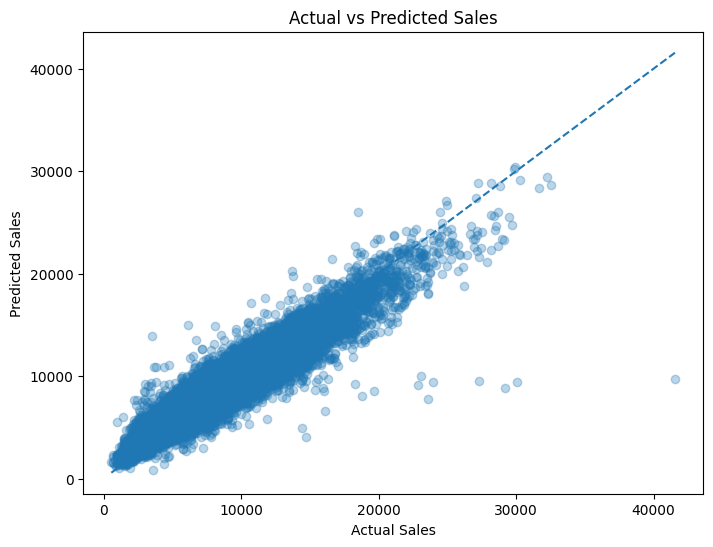

In [144]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))

plt.scatter(
    results['Actual_Sales'],
    results['Predicted_Sales'],
    alpha=0.3
)

# Perfect prediction line
min_sales = results['Actual_Sales'].min()
max_sales = results['Actual_Sales'].max()

plt.plot(
    [min_sales, max_sales],
    [min_sales, max_sales],
    linestyle='--'
)

plt.xlabel('Actual Sales')
plt.ylabel('Predicted Sales')
plt.title('Actual vs Predicted Sales')

plt.show()

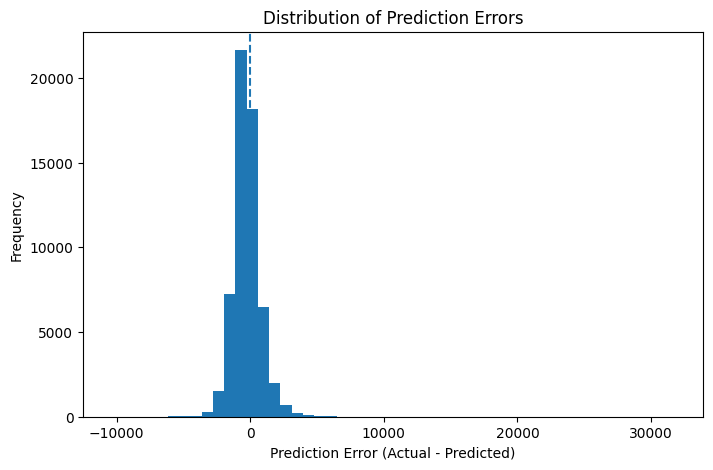

In [145]:
plt.figure(figsize=(8, 5))

plt.hist(
    results['Error'],
    bins=50
)

plt.axvline(
    x=0,
    linestyle='--'
)

plt.xlabel('Prediction Error (Actual - Predicted)')
plt.ylabel('Frequency')
plt.title('Distribution of Prediction Errors')

plt.show()

In [146]:
print("Mean Error:",
      results['Error'].mean())

print("Median Error:",
      results['Error'].median())

print("Mean Absolute Error:",
      results['Absolute_Error'].mean())

Mean Error: -251.7380070578055
Median Error: -323.52734375
Mean Absolute Error: 789.9434157438217


**Finding where the model performs worst**

In [147]:
worst_predictions = results.nlargest(
    20,
    'Absolute_Error'
)

worst_predictions[
    [
        'Store',
        'DayOfWeek',
        'Promo',
        'StoreType',
        'Actual_Sales',
        'Predicted_Sales',
        'Error',
        'Absolute_Error'
    ]
]

,Store,DayOfWeek,Promo,StoreType,Actual_Sales,Predicted_Sales,Error,Absolute_Error
44393,909,1,0,a,41551,9755.780273,31795.219727,31795.219727
43278,909,2,0,a,30038,9420.994141,20617.005859,20617.005859
35971,292,1,1,a,29161,8855.154297,20305.845703,20305.845703
28750,876,1,0,a,27330,9517.711914,17812.288086,17812.288086
34856,292,2,1,a,23584,7753.771484,15830.228516,15830.228516
27635,876,2,0,a,23927,9421.550781,14505.449219,14505.449219
46623,909,6,0,a,22882,9167.896484,13714.103516,13714.103516
13173,909,1,0,a,23081,10031.216797,13049.783203,13049.783203
26520,876,3,0,a,19665,8582.436523,11082.563477,11082.563477
67082,183,1,1,a,18797,8060.015625,10736.984375,10736.984375


In [148]:
xgb_model = best_xgb.named_steps['model']

In [149]:
feature_names = best_xgb.named_steps[
    'preprocessor'
].get_feature_names_out()

print("Number of features:", len(feature_names))
print(feature_names)

Number of features: 27
['cat__StoreType_a' 'cat__StoreType_b' 'cat__StoreType_c'
 'cat__StoreType_d' 'cat__Assortment_a' 'cat__Assortment_b'
 'cat__Assortment_c' 'cat__StateHoliday_0' 'cat__StateHoliday_a'
 'cat__StateHoliday_b' 'cat__StateHoliday_c' 'remainder__Store'
 'remainder__DayOfWeek' 'remainder__Promo' 'remainder__SchoolHoliday'
 'remainder__CompetitionDistance' 'remainder__Promo2' 'remainder__Year'
 'remainder__Month' 'remainder__Day' 'remainder__WeekOfYear'
 'remainder__Quarter' 'remainder__IsWeekend'
 'remainder__CompetitionInfoMissing' 'remainder__CompetitionMonths'
 'remainder__Promo2Months' 'remainder__Promo2ThisMonth']


In [150]:
import pandas as pd

feature_importance = pd.DataFrame({
    'Feature': feature_names,
    'Importance': xgb_model.feature_importances_
})

feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(15)

,Feature,Importance
1,cat__StoreType_b,0.263014
13,remainder__Promo,0.113761
16,remainder__Promo2,0.080773
15,remainder__CompetitionDistance,0.069274
11,remainder__Store,0.057275
6,cat__Assortment_c,0.048576
4,cat__Assortment_a,0.045614
2,cat__StoreType_c,0.040089
3,cat__StoreType_d,0.037775
23,remainder__CompetitionInfoMissing,0.035234


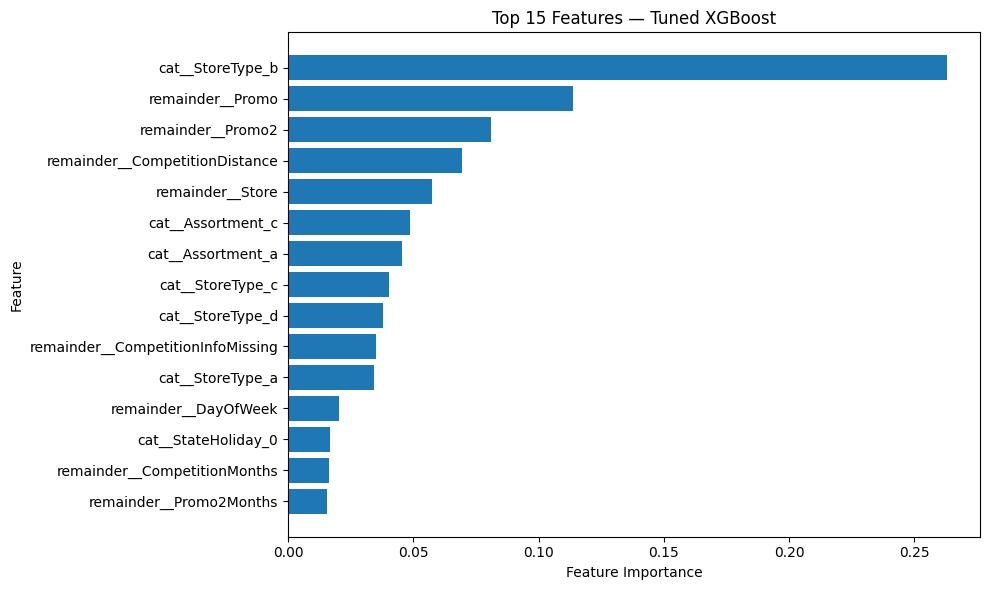

In [151]:
import matplotlib.pyplot as plt

top_features = feature_importance.head(15)

plt.figure(figsize=(10, 6))

plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance'][::-1]
)

plt.xlabel('Feature Importance')
plt.ylabel('Feature')
plt.title('Top 15 Features — Tuned XGBoost')

plt.tight_layout()
plt.show()

Promo was one of the most influential features used by the XGBoost model when generating sales predictions.

# **Final Model**

In [152]:
import joblib

joblib.dump(
    best_xgb,
    'rossmann_xgboost_pipeline.pkl'
)

['rossmann_xgboost_pipeline.pkl']

In [153]:
loaded_model = joblib.load(
    'rossmann_xgboost_pipeline.pkl'
)

print(loaded_model)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('cat',
                                                  OneHotEncoder(handle_unknown='ignore'),
                                                  ['StoreType', 'Assortment',
                                                   'StateHoliday'])])),
                ('model',
                 XGBRegressor(base_score=None, booster=None, callbacks=None,
                              colsample_bylevel=None, colsample_bynode=None,
                              colsample_bytree=0.8, device=None,
                              early_stopping_rounds=None...
                              feature_types=None, feature_weights=None,
                              gamma=None, grow_policy=None,
                              importance_type=None,
                              interaction_constraints=None, learning_rate=0.1,
                              max_bin=None

# **Model Performance Comparison**

In [154]:
model_comparison = pd.DataFrame({
    'Model': [
        'Mean Baseline',
        'Linear Regression',
        'Random Forest',
        'XGBoost',
        'Tuned XGBoost'
    ],
    'MAE': [
        2278.55,
        1974.47,
        954.25,
        868.52,
        789.94
    ],
    'RMSE': [
        3118.90,
        2677.64,
        1404.00,
        1180.36,
        1071.64
    ],
    'RMSPE (%)': [
        55.66,
        48.50,
        20.37,
        20.45,
        18.27
    ],
    'R2': [
        -0.0050,
        0.2593,
        0.7963,
        0.8561,
        0.8814
    ]
})

model_comparison

,Model,MAE,RMSE,RMSPE (%),R2
0,Mean Baseline,2278.55,3118.90,55.66,-0.0050
1,Linear Regression,1974.47,2677.64,48.50,0.2593
2,Random Forest,954.25,1404.00,20.37,0.7963
3,XGBoost,868.52,1180.36,20.45,0.8561
4,Tuned XGBoost,789.94,1071.64,18.27,0.8814


In [155]:
train_pred = best_xgb.predict(X_train)

print("Training Results")
evaluate_model(y_train, train_pred)

print("\nValidation Results")
evaluate_model(y_val, tuned_xgb_pred)

Training Results
MAE   : 475.50
RMSE  : 682.02
RMSPE : 18.28%
R²    : 0.9517

Validation Results
MAE   : 789.94
RMSE  : 1071.64
RMSPE : 18.27%
R²    : 0.8814


The final XGBoost model achieved an R² of 0.952 on training data and 0.881 on the chronological validation period. Validation MAE was approximately 790 sales units and RMSPE was 18.27%. There was a moderate train-validation gap, so I experimented with stronger regularization, but it reduced validation performance. Therefore, I retained the original tuned model based on its superior out-of-sample performance.